Attentional Seq2seq 기반 한-영 기계 번역 모델 개발 및 성능 분석
1. 데이터 전처리 및 코퍼스 구축 (Data Preprocessing)
성공적인 모델 학습을 위해 언어별 특성에 맞춘 고도화된 전처리를 수행하였습니다.

중복 제거 및 병렬성 유지 : df.drop_duplicates(ignore_index=True)
한국어 전처리 (Mecab):
영어 전처리 및 토큰화:
데이터 필터링: 학습 효율성을 극대화하기 위해 토큰 길이를 40 이하로 제한한 kor_corpus와 eng_corpus를 최종 구축하였습니다.

2. 모델 아키텍처 (Model Architecture)
본 프로젝트는 문맥의 핵심 정보를 동적으로 포착하는 Attention 메커니즘 기반의 Seq2seq 구조를 채택하였습니다.

Encoder: 입력된 한국어 시퀀스를 고정된 크기의 벡터가 아닌, 각 시점의 Hidden State로 인코딩합니다.

Attention Mechanism: 디코더가 매 시점 출력 단어를 예측할 때, 인코더의 특정 부분(중요도가 높은 단어)에 집중할 수 있도록 가중치를 계산합니다.

Decoder: Attention 가중치가 반영된 Context Vector를 입력받아 최종 영어 번역문을 생성합니다.

3. 학습 과정 및 결과 (Training & Results)
학습 파라미터 최적화를 통해 안정적인 수렴 과정을 확인하였습니다.

Loss Convergence: 훈련 과정에서 Training Loss가 일관되게 하락하며 모델이 데이터의 패턴을 안정적으로 학습하고 있음을 입증하였습니다.

최적화: Adam Optimizer 등을 활용하여 역전파(Backpropagation) 과정에서의 경사 하강이 효율적으로 이루어졌습니다.


4. 모델 테스트 및 번역 성능 평가 (Evaluation)
추론(Inference)을 위한 전용 디코더 모델을 구축하여 실제 번역 성능을 테스트한 결과입니다.

번역 품질: 테스트 데이터 입력 시, 문법적으로 완벽하지 않더라도 문장의 핵심 의미가 통하는 수준의 번역문 생성을 확인하였습니다.

정답 유사도: 모델이 생성한 번역문이 Ground Truth(정답지)와 의미적/구조적으로 높은 유사성을 보임을 확인하였습니다.

추론 로직: 테스트용 디코더가 <start> 토큰부터 <end> 토큰이 나올 때까지 반복적으로 단어를 생성하는 워크플로우가 정상적으로 작동함을 검증하였습니다.

5. 결론 및 향후 과제
본 프로젝트를 통해 데이터 정제 - 형태소 분석 - Attention 기반 모델링 - 추론으로 이어지는 번역 시스템의 전 과정을 성공적으로 구현하였습니다.

In [50]:
# from konlpy.tag import Mecab
#
!pip install python-mecab-ko
!pip install konlpy
from mecab import MeCab
mecab = MeCab()

print(mecab.morphs("이제 에러 없이 잘 돌아가나요?"))

try:
    # 기본 호출
    # mecab = Mecab()
    print("Mecab 로드 성공:", mecab.morphs("아버지가방에들어가신다"))
except Exception as e:
    print("에러 발생:", e)

['이제', '에러', '없이', '잘', '돌아가', '나요', '?']
Mecab 로드 성공: ['아버지', '가', '방', '에', '들어가', '신다']


In [1]:
!sudo apt update
!sudo apt install openjdk-17-jdk -y
!echo 'export JAVA_HOME=$(dirname $(dirname $(readlink -f $(which java))))' >> ~/.bashrc
!source ~/.bashrc

!pip install konlpy

Hit:1 http://security.ubuntu.com/ubuntu noble-security InRelease
Hit:2 http://archive.ubuntu.com/ubuntu noble InRelease0m
Hit:3 http://archive.ubuntu.com/ubuntu noble-updates InRelease
Hit:4 http://archive.ubuntu.com/ubuntu noble-backports InRelease
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
110 packages can be upgraded. Run 'apt list --upgradable' to see them.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
openjdk-17-jdk is already the newest version (17.0.18+8-1~24.04.1).
0 upgraded, 0 newly installed, 0 to remove and 110 not upgraded.


In [2]:
!pip install python-mecab-ko

In [3]:

!pip install konlpy

In [4]:
!mkdir -p ~/work/s2s_translation

In [5]:
!sudo apt update
!sudo apt-get install -y fonts-nanum
!pip install sentencepiece

Hit:1 http://security.ubuntu.com/ubuntu noble-security InRelease
Hit:2 http://archive.ubuntu.com/ubuntu noble InRelease
Hit:3 http://archive.ubuntu.com/ubuntu noble-updates InRelease
Hit:4 http://archive.ubuntu.com/ubuntu noble-backports InRelease
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
110 packages can be upgraded. Run 'apt list --upgradable' to see them.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 110 not upgraded.


In [6]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as ticker
import logging

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

fontpath = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"
fontprop = fm.FontProperties(fname=fontpath, size=12)
plt.rcParams["font.family"] = fontprop.get_name()

print(f"설정된 폰트: {fontprop.get_name()}")

설정된 폰트: NanumBarunGothic


In [25]:
import os
import re
import urllib.request
import zipfile
import sentencepiece as spm
import pandas as pd

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

from tqdm import tqdm
import random
from mecab import MeCab

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.__version__)

2.7.1+cu118


In [26]:
dataset_dir = os.path.expanduser("work/s2s_translation/datasets")
zip_path = os.path.join(dataset_dir, "korean-english-park.train.tar.gz")

print(f"zip_path: {zip_path}")
# !file zip_path

zip_path: work/s2s_translation/datasets/korean-english-park.train.tar.gz


In [27]:
!sudo apt-get install file -y

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
file is already the newest version (1:5.45-3build1).
0 upgraded, 0 newly installed, 0 to remove and 110 not upgraded.


In [28]:
!tar -zxvf work/s2s_translation/datasets/korean-english-park.train.tar.gz




korean-english-park.train.en
korean-english-park.train.ko


In [29]:
!file work/s2s_translation/datasets/korean-english-park.train.tar.gz


work/s2s_translation/datasets/korean-english-park.train.tar.gz: gzip compressed data, last modified: Tue Oct 14 03:45:20 2014, from Unix, original size modulo 2^32 25722880


In [30]:
dataset_dir = os.path.expanduser("work/s2s_translation/datasets")
os.makedirs(dataset_dir, exist_ok=True)

zip_path = os.path.join(dataset_dir, "korean-english-park.train.tar.gz")

if not os.path.exists(zip_path):
    print("데이터 다운로드 중...")
    #url = "http://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip"
    url = "https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora/refs/heads/master/korean-english-news-v1/korean-english-park.train.tar.gz"
    urllib.request.urlretrieve(url, zip_path)
    print("다운로드 완료!")

data_folder = os.path.join(dataset_dir, "kor-eng")
import tarfile

print(f"zip_path: {zip_path}")
# Read from a tar.gz file
# Use mode 'r:gz' for explicit gzip compression handling or let it infer
with tarfile.open(zip_path, 'r:*') as tf:
    # Extract all contents
    tf.extractall(path=data_folder)
    
# if not os.path.exists(data_folder):
#     print("압축 해제 중...")
#     with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#         zip_ref.extractall(dataset_dir)
#     print("압축 해제 완료!")

path_to_file = os.path.join(data_folder, "korean-english-park.train")

print("데이터셋 디렉토리:", os.listdir(dataset_dir))

zip_path: work/s2s_translation/datasets/korean-english-park.train.tar.gz


/tmp/ipykernel_12715/591433664.py:21: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tf.extractall(path=data_folder)


데이터셋 디렉토리: ['.ipynb_checkpoints', 'korean-english-park.train.tar.gz', 'kor-eng']


In [31]:
df_ko = pd.read_csv(path_to_file + ".ko", sep = "\r\n", names =["kor"])
df_en = pd.read_csv(path_to_file + ".en", sep = "\r\n", names =["eng"])


# df = pd.read_csv(path_to_file, sep = "\t", names = ["en", "ko"])
print(df_ko.head())
print(df_en.head())

df = df_ko.join(df_en)
print(df)

/tmp/ipykernel_12715/253968850.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df_ko = pd.read_csv(path_to_file + ".ko", sep = "\r\n", names =["kor"])
/tmp/ipykernel_12715/253968850.py:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df_en = pd.read_csv(path_to_file + ".en", sep = "\r\n", names =["eng"])


                                                 kor
0               개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐?"
1  모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하...
2                         그러나 이것은 또한 책상도 필요로 하지 않는다.
3  79.95달러하는 이 최첨단 무선 광마우스는 허공에서 팔목, 팔, 그외에 어떤 부분...
4  정보 관리들은 동남 아시아에서의 선박들에 대한 많은 (테러) 계획들이 실패로 돌아갔...
                                                 eng
0  Much of personal computing is about "can you t...
1  so a mention a few weeks ago about a rechargea...
2  Like all optical mice, But it also doesn't nee...
3  uses gyroscopic sensors to control the cursor ...
4  Intelligence officials have revealed a spate o...
                                                     kor  \
0                   개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐?"   
1      모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하...   
2                             그러나 이것은 또한 책상도 필요로 하지 않는다.   
3      79.95달러하는 이 최첨단 무선 광마우스는 허공에서 팔목, 팔, 그외에 어떤 부분...   
4      정보 관리들은 동남 아시아에서의 선박들에 대한 많은 (테러) 계획들이 실패로 돌아갔...   
... 

In [32]:
cleaned_corpus = df.drop_duplicates(ignore_index=True)

print(cleaned_corpus)

                                                     kor  \
0                   개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐?"   
1      모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하...   
2                             그러나 이것은 또한 책상도 필요로 하지 않는다.   
3      79.95달러하는 이 최첨단 무선 광마우스는 허공에서 팔목, 팔, 그외에 어떤 부분...   
4      정보 관리들은 동남 아시아에서의 선박들에 대한 많은 (테러) 계획들이 실패로 돌아갔...   
...                                                  ...   
78936  “우리는 3월 8일 김승연 회장과 그의 아들이 보복폭행에 가담한 혐의를 찾기 위해 ...   
78937   월요일 술집 종업원 6명은 김회장과 아들에게 폭행을 당했음을 진술했다고 경찰은 말했다.   
78938                       그러나 불충분한 증거 확보로 수사에 어려움이 있다.   
78939                  김회장과 그의 아들은 보복폭행 혐의를 강력히 부인하고 있다.   
78940  경찰은 김회장의 집무실에서 추가 증거를 찾은 이후 가능한 한 오늘 김회장과 아들을 ...   

                                                     eng  
0      Much of personal computing is about "can you t...  
1      so a mention a few weeks ago about a rechargea...  
2      Like all optical mice, But it also doesn't nee...  
3      uses gyroscopic sensors to control t

In [33]:
def preprocess_sentence(sentence):
    sentence = sentence.lower().strip()

    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)
    sentence = re.sub(r"[^a-zA-Z?.!,가-힣ㄱ-ㅎ-ㅣ]+", " ", sentence)

    sentence = sentence.strip()

    return sentence

print("슝~")

슝~


In [34]:
# '점수' 칼럼이 40 미만인 데이터만 분리
df_under_40 = cleaned_corpus[ (cleaned_corpus['eng'].str.len() < 40) ].copy()
df_under_40 = df_under_40.reset_index(drop=True)
df_under_40

,kor,eng
0,또 다른 60대의 로보트가 경비 일을 하고 있다.,Another 60 robots work in surveillance.
1,다른 4명은 아직도 실종된 상태이다.,Four others are still missing.
2,북한이 핵무기를 개발했다고 처음으로 밝혔다.,it has developed a nuclear weapon.
3,김소현은 그저 잠을 많이 자려 한다.,Kim So Hyon would just sleep a lot.
4,선례가 하나 있다.,There is a precedent.
...,...,...
2832,TOEIC 독해,The vote is expected late today.
2833,"잘 알겠습니다, 워렌 기자.","Okay, thank you, Warren."
2834,오늘 아침 미국자동차협회 발표 전국 평균 휘발유 가격은 갤론당 2.42달러입니다.,AAA gasoline this morning;
2835,AP 라디오 뉴스입니다.,a national average $2.42 a gallon.


In [35]:
cleaned_corpus_df = df_under_40[:30000]

cleaned_corpus_df["kor"] = cleaned_corpus_df["kor"].apply(preprocess_sentence)
cleaned_corpus_df["eng"] = cleaned_corpus_df["eng"].apply(lambda x: preprocess_sentence(x))

cleaned_corpus_df

,kor,eng
0,또 다른 대의 로보트가 경비 일을 하고 있다 .,another robots work in surveillance .
1,다른 명은 아직도 실종된 상태이다 .,four others are still missing .
2,북한이 핵무기를 개발했다고 처음으로 밝혔다 .,it has developed a nuclear weapon .
3,김소현은 그저 잠을 많이 자려 한다 .,kim so hyon would just sleep a lot .
4,선례가 하나 있다 .,there is a precedent .
...,...,...
2832,toeic 독해,the vote is expected late today .
2833,"잘 알겠습니다 , 워렌 기자 .","okay , thank you , warren ."
2834,오늘 아침 미국자동차협회 발표 전국 평균 휘발유 가격은 갤론당 . 달러입니다 .,aaa gasoline this morning
2835,ap 라디오 뉴스입니다 .,a national average . a gallon .


In [36]:
cleaned_corpus_df.loc[2834]


kor    오늘 아침 미국자동차협회 발표 전국 평균 휘발유 가격은 갤론당 . 달러입니다 .
eng                       aaa gasoline this morning
Name: 2834, dtype: object

In [37]:
cleaned_corpus_df["kor"].to_csv("kor_corpus.txt", index=False, header=False, sep="\n", encoding="utf-8")
cleaned_corpus_df["eng"].to_csv("eng_corpus.txt", index=False, header=False, sep="\n", encoding="utf-8")

print("파일 저장 완료: kor_corpus.txt, eng_corpus.txt")

파일 저장 완료: kor_corpus.txt, eng_corpus.txt


In [38]:
vocab_size = 2900
pad_id = 0
bos_id = 1
eos_id = 2
unk_id = 3

spm.SentencePieceTrainer.train(
    input = "kor_corpus.txt",
    model_prefix = "encoder_spm",
    vocab_size = vocab_size,
    pad_id = pad_id,
    bos_id = bos_id,
    eos_id = eos_id,
    unk_id = unk_id
)

spm.SentencePieceTrainer.train(
    input = "eng_corpus.txt",
    model_prefix = "decoder_spm",
    vocab_size = vocab_size,
    pad_id = pad_id,
    bos_id = bos_id,
    eos_id = eos_id,
    unk_id = unk_id
)

sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: kor_corpus.txt
  input_format: 
  model_prefix: encoder_spm
  model_type: UNIGRAM
  vocab_size: 2900
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 3
  bos_id: 1
  eos_id: 2
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_differential_privacy: 0
  d

In [39]:
encoder_tokenizer = spm.SentencePieceProcessor()
encoder_tokenizer.load("encoder_spm.model")

decoder_tokenizer = spm.SentencePieceProcessor()
decoder_tokenizer.load("decoder_spm.model")

True

In [40]:
cleaned_corpus_df

,kor,eng
0,또 다른 대의 로보트가 경비 일을 하고 있다 .,another robots work in surveillance .
1,다른 명은 아직도 실종된 상태이다 .,four others are still missing .
2,북한이 핵무기를 개발했다고 처음으로 밝혔다 .,it has developed a nuclear weapon .
3,김소현은 그저 잠을 많이 자려 한다 .,kim so hyon would just sleep a lot .
4,선례가 하나 있다 .,there is a precedent .
...,...,...
2832,toeic 독해,the vote is expected late today .
2833,"잘 알겠습니다 , 워렌 기자 .","okay , thank you , warren ."
2834,오늘 아침 미국자동차협회 발표 전국 평균 휘발유 가격은 갤론당 . 달러입니다 .,aaa gasoline this morning
2835,ap 라디오 뉴스입니다 .,a national average . a gallon .


In [41]:
kor_sample = cleaned_corpus_df["kor"][2000]
eng_sample = cleaned_corpus_df["eng"][2000]
print(kor_sample)
print(eng_sample)

다른 병원들도 경계 태세에 들어갔다 .
other hospitals were on alert .


In [82]:
enc_token = encoder_tokenizer.encode(eng_sample)
enc_token = [encoder_tokenizer.bos_id()] + enc_token + [encoder_tokenizer.eos_id()]
enc_token

# 토큰화 수행
# 한국어: Mecab 형태소 분석
kor_tokens = mecab.morphs(kor_sample)
print(kor_tokens)
# 영어: split() 이용
eng_tokens = enc_token #.split()
kor_token = encoder_tokenizer.encode(kor_tokens)
kor_tokens = [encoder_tokenizer.bos_id()] + kor_token + [encoder_tokenizer.eos_id()]

print(kor_tokens)
print(eng_tokens)

# enc_decoding = encoder_tokenizer.decode(kor_tokens)
# print(enc_decoding)


['다른', '병원', '들', '도', '경계', '태세', '에', '들어갔', '다', '.']
[1, [4, 9, 99], [772], [4, 56], [4, 21], [310, 293], [1147, 332], [4, 13], [1020], [4, 9], [5], 2]
[1, 4, 309, 183, 256, 1995, 4, 940, 84, 736, 510, 518, 84, 350, 1995, 48, 998, 4, 1369, 378, 183, 5, 2]


In [56]:
enc_decoding = encoder_tokenizer.decode(enc_token)
enc_decoding

'other hospitals were on alert .'

In [89]:
class TranslationDataset(Dataset):
    def __init__(self, data, encoder_tokenizer, decoder_tokenizer, max_len):
        self.data = data
        self.encoder_tokenizer = encoder_tokenizer
        self.decoder_tokenizer = decoder_tokenizer
        self.max_len = max_len
        self.pad_id = 0
        self.bos_id = 1
        self.eos_id = 2

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        src_text = self.data.iloc[idx]['kor']
        trg_text = self.data.iloc[idx]['eng']
        
        # [수정 포인트] 한국어는 Mecab으로 형태소 분리 후 인코딩
        src_preprocessed = tokenize_kor(src_text)
        src_ids = self.encoder_tokenizer.encode(src_preprocessed)
        
        #src_ids = self.encoder_tokenizer.encode(src_text)
        trg_ids = self.decoder_tokenizer.encode(trg_text)

        src_ids = src_ids[:self.max_len]

        # Decoder의 입력에는 START_TOKEN과 END_TOKEN을 추가해줍니다. 단, 최대 길이 제한을 적용시킵니다.
        src_input = [self.bos_id] + src_ids[:self.max_len - 2] + [self.eos_id]
        trg_input = [self.bos_id] + trg_ids[:self.max_len - 2] + [self.eos_id]
        trg_label = trg_ids[:self.max_len - 1] + [self.eos_id]

        # 길이가 짧은 경우 PAD_TOKEN을 추가해줍니다.
        src_input = src_input + [self.pad_id] * (self.max_len - len(src_input))
        # src_ids = src_ids + [self.pad_id] * (self.max_len - len(src_ids))
        trg_input = trg_input + [self.pad_id] * (self.max_len - len(trg_input))
        trg_label = trg_label + [self.pad_id] * (self.max_len - len(trg_label))

        return torch.tensor(src_input), torch.tensor(trg_input), torch.tensor(trg_label)

In [90]:
# from konlpy.tag import Mecab
# mecab = MeCab()

print(mecab.morphs("이제 에러 없이 잘 돌아가나요?"))

try:
    # 기본 호출
    # mecab = Mecab()
    print("Mecab 로드 성공:", mecab.morphs("아버지가방에들어가신다"))
except Exception as e:
    print("에러 발생:", e)

def tokenize_kor(text):
    # Mecab으로 형태소 분석 후 공백으로 연결된 문자열 반환
    return " ".join(mecab.morphs(text))

['이제', '에러', '없이', '잘', '돌아가', '나요', '?']
Mecab 로드 성공: ['아버지', '가', '방', '에', '들어가', '신다']


In [91]:
train_ratio = 0.8  # 전체 길이의 80%
MAX_LEN = 30 # 임의의 값
BATCH_SIZE = 64

train_data = cleaned_corpus_df.sample(frac=train_ratio, random_state=42)  # 80% 훈련 데이터
valid_data = cleaned_corpus_df.drop(train_data.index)

train_data.reset_index(drop=True, inplace=True)
valid_data.reset_index(drop=True, inplace=True)

train_data = TranslationDataset(train_data, encoder_tokenizer, decoder_tokenizer, max_len=MAX_LEN)
validation_data = TranslationDataset(valid_data, encoder_tokenizer, decoder_tokenizer, max_len=MAX_LEN)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
validation_loader = DataLoader(validation_data, batch_size=BATCH_SIZE, shuffle=False)

In [92]:
for src, trg_input, trg_label in train_loader:
    print(src.shape, trg_input.shape, trg_label.shape)
    break

torch.Size([64, 30]) torch.Size([64, 30]) torch.Size([64, 30])


In [93]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()

        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        # hidden: (batch_size, hidden_dim)
        # encoder_outputs: (src_len, batch_size, hidden_dim)

        src_len = encoder_outputs.shape[0]

        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)  # (batch_size, src_len, hidden_dim)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # (batch_size, src_len, hidden_dim)

        energy = torch.tanh(self.W1(encoder_outputs) + self.W2(hidden))  # (batch_size, src_len, hidden_dim)
        attention = self.v(energy).squeeze(2)  # (batch_size, src_len)

        return nn.functional.softmax(attention, dim=1)  # (batch_size, src_len)

In [94]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim):
        super().__init__()

        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hidden_dim)

    def forward(self, src):
        # src : (src_len, batch_size)
        embedded = self.embedding(src)  # embedded : (src_len, batch_size, emb_dim)
        outputs, hidden = self.rnn(embedded)  # outputs : (src_len, batch_size, hidden_dim)

        return outputs, hidden

In [95]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, attention):
        super(Decoder, self).__init__()

        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        # Decoder RNN에는 embedding만 입력
        self.rnn = nn.GRU(emb_dim, hidden_dim)
        # 출력층에는 hidden state와 attention value가 결합되어 입력
        self.fc_out = nn.Linear(hidden_dim + hidden_dim, output_dim)

    def forward(self, input, hidden, encoder_outputs):
        # input : (batch_size,)
        # hidden : (batch_size, hidden_dim)
        # encoder_outputs : (src_len, batch_size, hidden_dim)
        input = input.unsqueeze(0)  # input : (1, batch_size)
        embedded = self.embedding(input)  # embedded : (1, batch_size, emb_dim)

        # attention distribution을 계산합니다. decoder의 이전 hidden state, s_{t-1}와 encoder의 H가 입력됩니다.
        a = self.attention(hidden[-1], encoder_outputs)  # a : (batch_size, src_len)

        # H에 가중치를 부여해 attention value(Context vector) 계산
        a = a.unsqueeze(1)  # a : (batch_size, 1, src_len)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # encoder_outputs : (batch_size, src_len, hidden_dim)
        context = torch.bmm(a, encoder_outputs)  # context : (batch_size, 1, hidden_dim)
        context = context.permute(1, 0, 2)  # context : (1, batch_size, hidden_dim)

        output, hidden = self.rnn(embedded, hidden)

        # 출력층에서는 현재 hidden state와 context vector를 결합하여 예측값 생성
        output = output.squeeze(0)  # output : (batch_size, hidden_dim)
        context = context.squeeze(0)  # context : (batch_size, hidden_dim)
        prediction = self.fc_out(torch.cat((output, context), dim=1))  # (batch_size, output_dim)

        return prediction, hidden, a.squeeze(1)

In [96]:
class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg=None, max_len=30, bos_id = 1, eos_id=2):
        # 학습 모드에서는 trg_len 사용, 추론 모드에서는 max_len까지 동적 생성
        batch_size = src.shape[1]
        trg_vocab_size = self.decoder.fc_out.out_features

        # 조기 종료를 위해 tensor가 아닌 리스트 사용
        outputs = []

        # 시각화를 위해 attention 저장
        attentions = []

        # 인코더를 통해 context 생성
        encoder_outputs, hidden = self.encoder(src)

        if trg is not None:
            for t in range(0, trg.shape[0]):
                input = trg[t]
                output, hidden, attention = self.decoder(input, hidden, encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))

        else:
		    # inference에서는 target(정답)이 없기 때문에 sos_token을 생성해줍니다.
            input = torch.full((batch_size,), bos_id, dtype=torch.long, device=self.device)
            finished = torch.zeros(batch_size, dtype=torch.bool, device=self.device)

            for t in range(max_len):
                output, hidden, attention = self.decoder(input, hidden,  encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))
                top1 = output.argmax(1)
                input = top1

                # 조기 종료 조건
                finished |= (top1 == eos_id)
                if finished.all():
                    break

        outputs = torch.cat(outputs, dim=0)  # (trg_len, batch_size, output_dim)
        attentions = torch.cat(attentions, dim=0)  # (trg_len, batch_size, src_len)

        return outputs, attentions

In [97]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

input_dim = len(encoder_tokenizer)
output_dim = len(decoder_tokenizer)
emb_dim = 256
hid_dim = 512

In [98]:
encoder = Encoder(input_dim, emb_dim, hid_dim).to(device)
attention = BahdanauAttention(hid_dim).to(device)
decoder = Decoder(output_dim, emb_dim, hid_dim, attention).to(device)
model = Seq2SeqAttention(encoder, decoder, device).to(device)

In [99]:
print(model)

Seq2SeqAttention(
  (encoder): Encoder(
    (embedding): Embedding(2900, 256)
    (rnn): GRU(256, 512)
  )
  (decoder): Decoder(
    (attention): BahdanauAttention(
      (W1): Linear(in_features=512, out_features=512, bias=True)
      (W2): Linear(in_features=512, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(2900, 256)
    (rnn): GRU(256, 512)
    (fc_out): Linear(in_features=1024, out_features=2900, bias=True)
  )
)


In [100]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=pad_id)

print("슝~")

슝~


In [173]:

train_losses = []
val_losses = []
train_accs = []
val_accs = []

In [164]:

from torch.utils.data import TensorDataset, DataLoader, random_split
import copy
def train_val_loss_visualization(train_losses, val_losses, epochs=20):
    epochs_range = range(1, epochs + 1)

    if len(train_losses) < epochs:
        for i in range(epochs - len(train_losses)):
            train_losses.append(train_losses[-1])

    if len(val_losses) < epochs:
        for i in range(epochs - len(val_losses)):
            val_losses.append(val_losses[-1])

    plt.plot(epochs_range, train_losses, 'bo', label='Training loss')
    plt.plot(epochs_range, val_losses, 'r', label='Validation loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

train_losses = []
val_losses = []
train_accs = []
val_accs = []
def train_step(model, data_loader, optimizer, criterion, epoch):
    model.train()
    epoch_loss = 0
    running_loss = 0.0
    total = 0

    progress_bar = tqdm(data_loader, desc=f"Epoch {epoch+1}", leave=True)

    for src, trg_input, trg_label in progress_bar:
        # 모델의 입력 순서에 맞게 transpose 변환
        src = src.permute(1, 0).to(device)
        trg_input = trg_input.permute(1, 0).to(device)
        trg_label = trg_label.permute(1, 0).to(device)
        optimizer.zero_grad()

        outputs,_ = model(src, trg_input)
        
        # (trg_len, batch_size, output_dim)을 (batch_size * trg_len, output_dim)으로 변환
        outputs = outputs.reshape(-1, outputs.shape[-1])
        trg_label = trg_label.reshape(-1)

        loss = criterion(outputs, trg_label)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)

        optimizer.step()

        epoch_loss += loss.item()
        
        # predicted = (outputs.squeeze() > 0.5).float()
        # total += labels.size(0)

        progress_bar.set_postfix(loss=loss.item())

    train_losses.append(epoch_loss / len(data_loader))
    return epoch_loss / len(data_loader)

print("슝~")


슝~


In [165]:
%%time

# EPOCHS = 2  #10

# for epoch in range(EPOCHS):
#     train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
#     print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}')

CPU times: user 3 μs, sys: 0 ns, total: 3 μs
Wall time: 6.91 μs


In [166]:
def eval_step(model, data_loader, optimizer, criterion):
    model.eval()
    epoch_loss = 0
    total_loss = 0
    val_loss = 0.0
    val_total = 0

    for src, trg_input, trg_label in data_loader:
        # 모델의 입력 순서에 맞게 transpose 변환
        src = src.permute(1, 0).to(device)
        trg_input = trg_input.permute(1, 0).to(device)
        trg_label = trg_label.permute(1, 0).to(device)

        outputs,_ = model(src, trg_input)
        
        # (trg_len, batch_size, output_dim)을 (batch_size * trg_len, output_dim)으로 변환
        outputs = outputs.reshape(-1, outputs.shape[-1])
        trg_label = trg_label.reshape(-1)

        loss = criterion(outputs, trg_label)

        total_loss += loss.item()

        predicted = (outputs.squeeze() > 0.5).float()

    val_losses.append(epoch_loss / len(data_loader))
    # total += labels.size(0)
    return total_loss / len(data_loader)

print("슝~")

슝~


In [167]:
validation_loader

In [170]:
%%time

EPOCHS = 16

for epoch in range(EPOCHS):
    train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
    valid_loss = eval_step(model, validation_loader, optimizer, criterion)
    print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}, Validation Loss: {valid_loss:.4f}')

Epoch 1: 100%|██████████| 36/36 [00:04<00:00,  8.94it/s, loss=0.0978]


Epoch 1/16, Train Loss: 0.0718, Validation Loss: 5.9910


Epoch 2: 100%|██████████| 36/36 [00:04<00:00,  8.96it/s, loss=0.0602]


Epoch 2/16, Train Loss: 0.0658, Validation Loss: 6.0327


Epoch 3: 100%|██████████| 36/36 [00:03<00:00,  9.01it/s, loss=0.0514]


...

Epoch 14/16, Train Loss: 0.0562, Validation Loss: 6.2495


Epoch 15: 100%|██████████| 36/36 [00:03<00:00,  9.12it/s, loss=0.0369]


Epoch 15/16, Train Loss: 0.0562, Validation Loss: 6.2472


Epoch 16: 100%|██████████| 36/36 [00:04<00:00,  8.97it/s, loss=0.0588]


Epoch 16/16, Train Loss: 0.0549, Validation Loss: 6.2339
CPU times: user 1min 11s, sys: 592 ms, total: 1min 11s
Wall time: 1min 11s


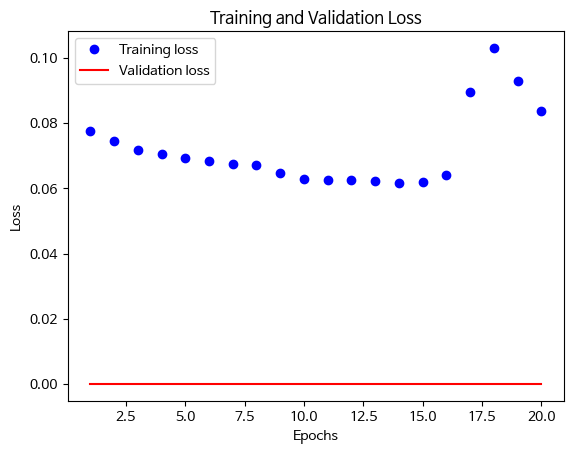

In [169]:
train_val_loss_visualization(train_losses, val_losses, 20)

/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


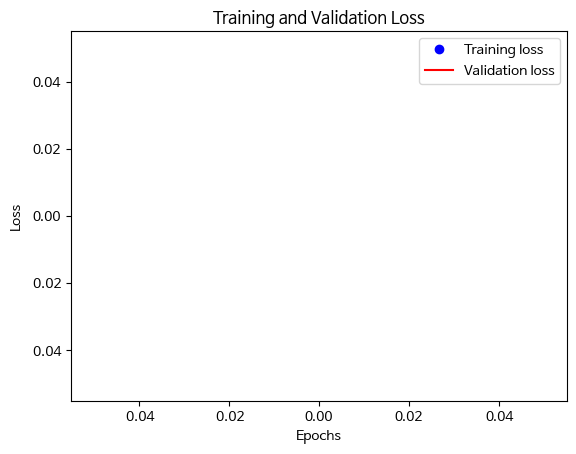

In [175]:
train_val_loss_visualization(train_losses, val_losses, 0)

In [176]:
def evaluate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=30):
    model.eval()

    sentence = preprocess_sentence(sentence)
    src_ids = encoder_tokenizer.encode(sentence)
    src_ids = src_ids[:max_len]
    src_ids = src_ids + [0] * (max_len - len(src_ids))  # 패딩 추가
    src_tensor = torch.tensor(src_ids).unsqueeze(1).to(device)  # (src_len, 1)

    with torch.no_grad():
        outputs, attentions = model(src_tensor, max_len=max_len)

    result = [decoder_tokenizer.decode([token.item()]) for token in outputs.argmax(2).squeeze(1)]

    if "<end>" in result:
        result = result[:result.index("<end>")]

    return result, sentence, attentions.squeeze(1).cpu().numpy()

In [177]:
def plot_attention(attention, sentence, predicted_sentence):
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.matshow(attention, cmap='viridis')

    fontdict = {'fontsize': 14}

    ax.set_xticks(range(len(sentence)))
    ax.set_xticklabels(sentence, fontdict=fontdict, rotation=90)

    ax.set_yticks(range(len(predicted_sentence)))
    ax.set_yticklabels(predicted_sentence, fontdict=fontdict)

    plt.show()

In [178]:
def translate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=30):
    result, sentence, attention = evaluate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len)

    print('Input: %s' % (sentence))
    print('Predicted translation: {}'.format(result))

    # Attention 크기 조정 (trg_len, src_len)
    attention = attention[:len(result), :len(sentence.split())]

    plot_attention(attention, sentence.split(), result)

Input: 다른 명은 아직도 실종된 상태이다 .
Predicted translation: ['but', 'not', 'in', 'this', 'way', '.', '']


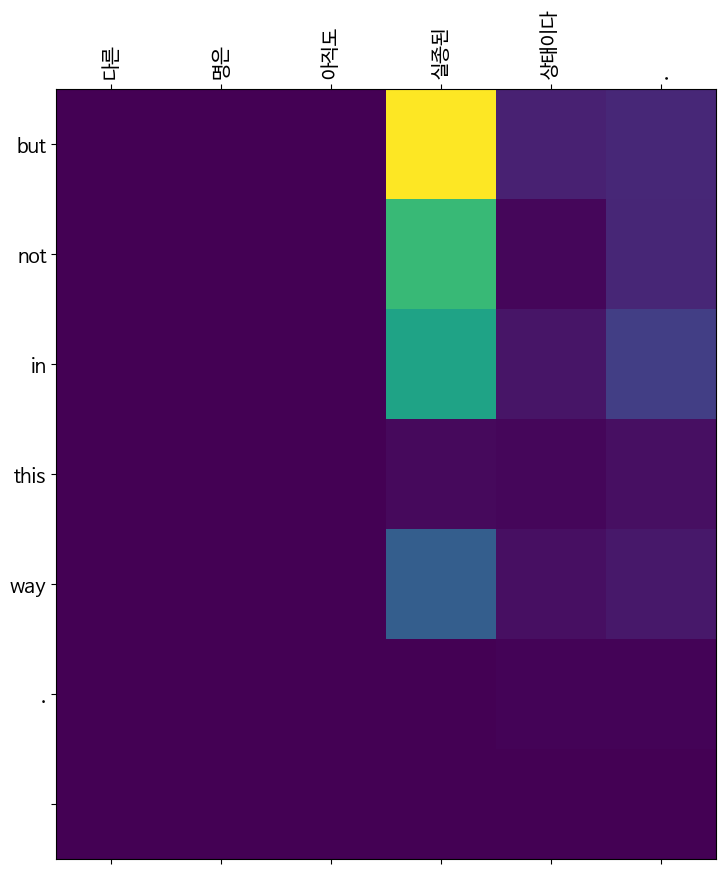

In [179]:
translate("다른 4명은 아직도 실종된 상태이다.", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

Input: 또 다른 대의 로보트가 경비 일을 하고 있다 .
Predicted translation: ['the', 'y', 'also', 'have', 'two', 'kid', 's', '.', '']


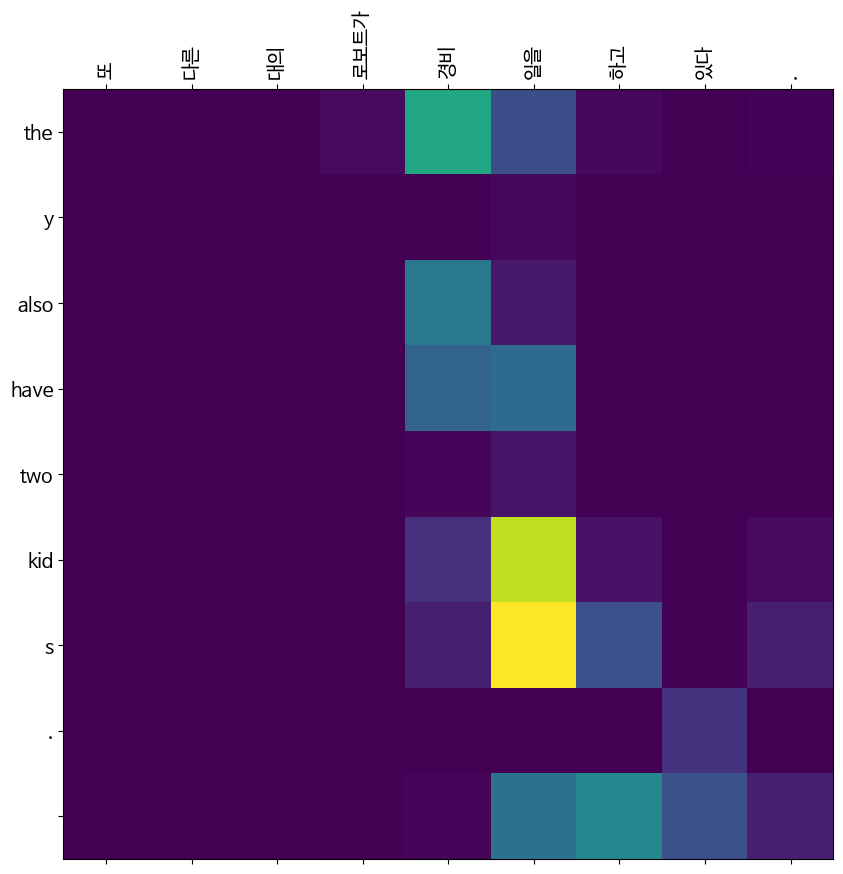

In [180]:
translate("또 다른 60대의 로보트가 경비 일을 하고 있다. ", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

Input: 선례가 하나 있다 .
Predicted translation: ['the', 'y', 're', 'act', 'ing', 'on', 'fear', '.', '']


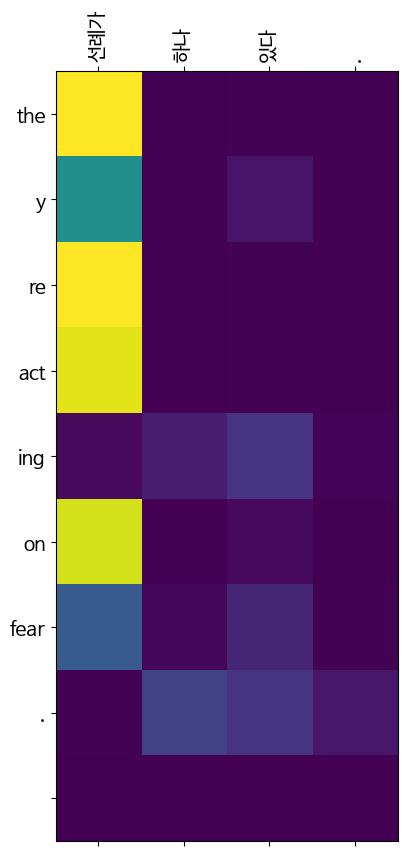

In [186]:
translate("선례가 하나 있다 .", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

Input: 오바마는 대통령이다 .
Predicted translation: ['obama', 'denie', 'd', 'accus', 'ing', 'for', 'the', 'family', '']


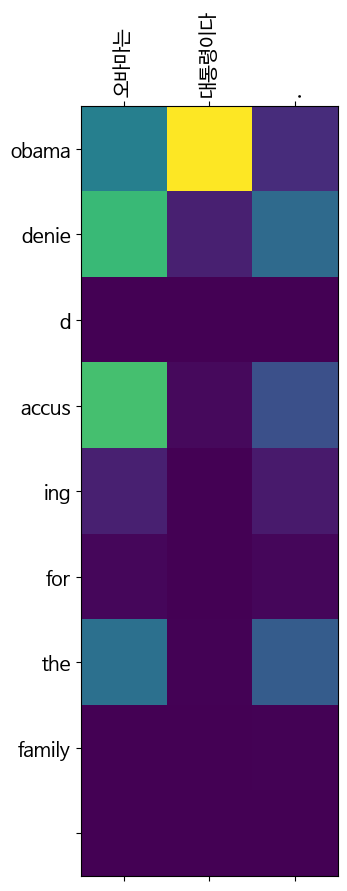

In [182]:
translate("오바마는 대통령이다.", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

Input: 시민들은 도시 속에 산다 .
Predicted translation: ['but', 'not', 'in', 'this', 'way', '.', '']


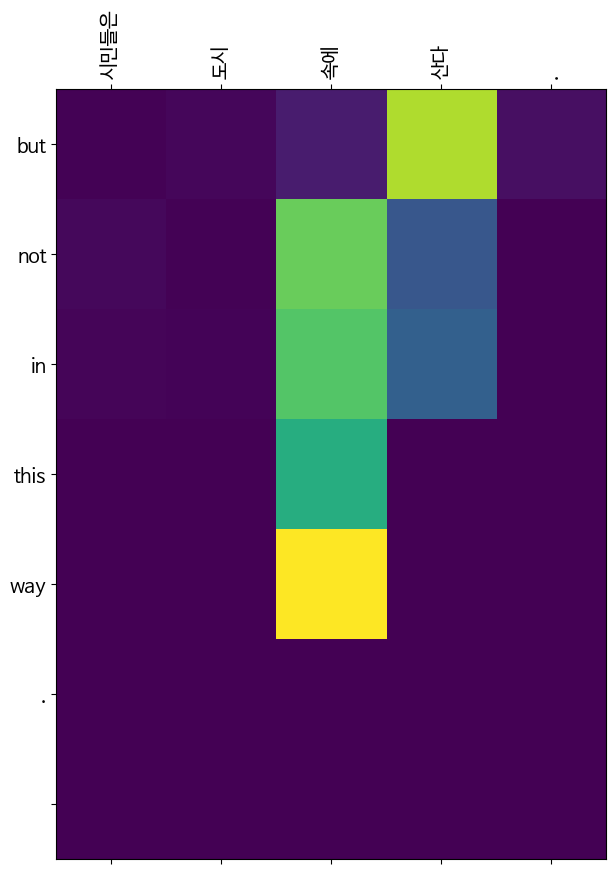

In [183]:
translate("시민들은 도시 속에 산다.", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

Input: 커피는 필요 없다 .
Predicted translation: ['the', 'y', 're', 'act', 'ing', 'on', 'the', 'rise', '.', '']


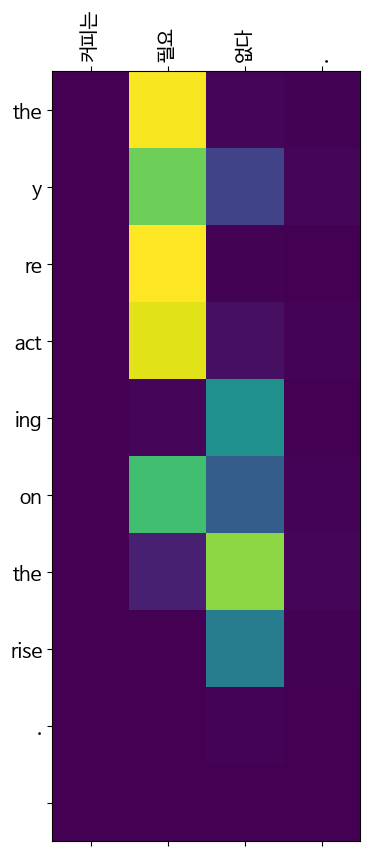

In [184]:
translate("커피는 필요 없다. ", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

Input: 일곱 명의 사망자가 발생했다 .
Predicted translation: ['b', 'oth', 'carrie', 'd', 'bag', 's', 'to', 'the', 'fu', 'ture', '.', '']


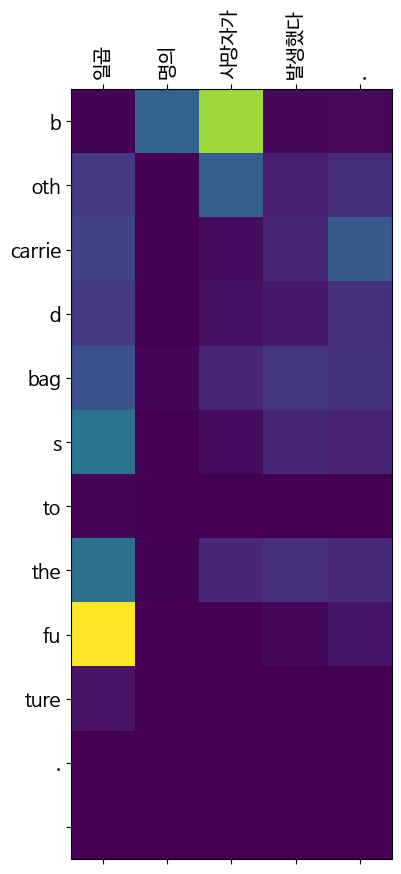

In [185]:
translate("일곱 명의 사망자가 발생했다.", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

Input: 또 다른 대의 로보트가 경비 일을 하고 있다 .
Predicted translation: ['the', 'y', 'do', 'have', 'some', 'bread', '?', '']


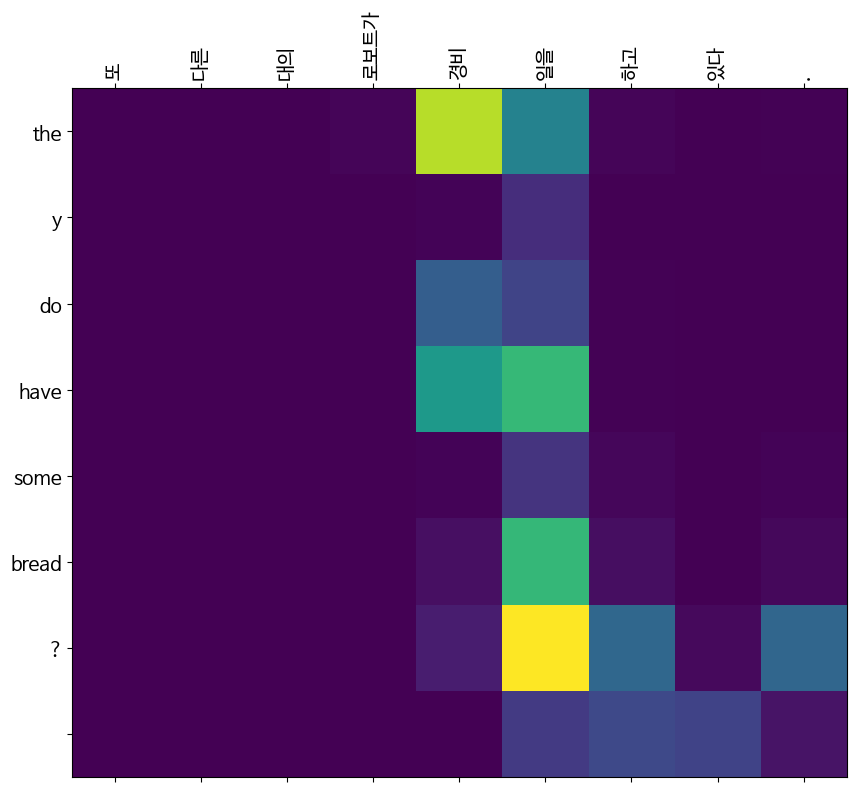

In [117]:
translate("또 다른 60대의 로보트가 경비 일을 하고 있다. ", model, encoder_tokenizer, decoder_tokenizer, max_len=30)